In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import qiskit_aer as qa
import matplotlib.pyplot as plt
import numpy as np
from qiskit_aer.noise import NoiseModel, pauli_error
from tqdm import tqdm

In [3]:
# Parameters
numiterations = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
bitflipprobs = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
nshots = 10000
resultsmat = np.zeros((len(numiterations), len(bitflipprobs)))

for ni in tqdm(range(len(numiterations))):
    for p in range(len(bitflipprobs)):
        bitflipprob = bitflipprobs[p]
        numiter = numiterations[ni]

        # Circuit with single qubit initialized to 0
        qreg = QuantumRegister(1, 'q')
        creg = ClassicalRegister(1, 'c')
        qc = QuantumCircuit(qreg, creg)

        # Create a noise model with bit-flip errors
        bitflip = pauli_error([('X', bitflipprob), ('I', 1 - bitflipprob)])
        noise_model = NoiseModel()
        noise_model.add_quantum_error(bitflip, ['id'], [0])

        # Apply idle gates to simulate noise
        for n in range(numiter):
            qc.id(qreg[0])

        # Measure qubit at the end of circuit
        qc.measure(qreg[0], creg[0])

        # Simulate the circuit 10000 times (shots=10000) using Qiskit Aer
        backend = qa.Aer.get_backend('qasm_simulator')
        job = backend.run(qc, shots=nshots, noise_model=noise_model)
        result = job.result()
        counts = result.get_counts(qc)
        try:
            resultsmat[ni, p] = counts['0'] / nshots
        except:
            resultsmat[ni, p] = 0
        
        #break
    #break

#qc.draw('mpl')

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:01<00:00,  7.57it/s]


In [4]:
# Expected results calculated from even-parity probability of binomial distribution
expectedmat = np.zeros((len(numiterations), len(bitflipprobs)))
for ni in range(len(numiterations)):
    for p in range(len(bitflipprobs)):
        expectedmat[ni, p] = (1 + (1 - 2 * bitflipprobs[p])**numiterations[ni]) / 2

In [5]:
resultsmat

array([[0.999 , 0.9986, 0.9949, 0.991 , 0.9792, 0.9467, 0.9002, 0.7929,
        0.6939, 0.5972, 0.4997],
       [0.9979, 0.9963, 0.9908, 0.9799, 0.9622, 0.9145, 0.8224, 0.6808,
        0.58  , 0.5129, 0.498 ],
       [0.9952, 0.99  , 0.9761, 0.9535, 0.9107, 0.7936, 0.6594, 0.5467,
        0.5015, 0.5019, 0.5017],
       [0.9904, 0.9822, 0.9525, 0.9099, 0.8334, 0.6826, 0.552 , 0.5098,
        0.5082, 0.4897, 0.504 ],
       [0.9793, 0.9588, 0.906 , 0.8363, 0.7144, 0.5571, 0.5016, 0.5011,
        0.5059, 0.4914, 0.5044],
       [0.9518, 0.9114, 0.8044, 0.683 , 0.5614, 0.5112, 0.4945, 0.4941,
        0.4963, 0.4906, 0.4904],
       [0.9097, 0.8353, 0.6858, 0.5571, 0.5047, 0.5105, 0.4981, 0.5067,
        0.5063, 0.5002, 0.4978],
       [0.8335, 0.7308, 0.5593, 0.5087, 0.4927, 0.5036, 0.5048, 0.4975,
        0.5031, 0.498 , 0.5009],
       [0.6907, 0.5714, 0.5082, 0.4983, 0.4898, 0.5023, 0.4939, 0.4862,
        0.4995, 0.5028, 0.5035],
       [0.5717, 0.5154, 0.4964, 0.4915, 0.5059, 0.4991,

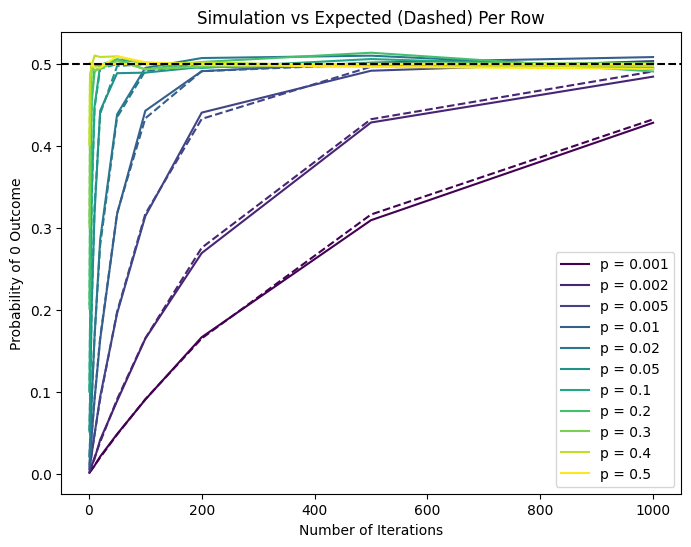

In [6]:
# Plot a row of resultsmat and expectedmat side by side

plt.figure(figsize=(8,6))
num_rows = len(bitflipprobs)
colors = plt.cm.viridis(np.linspace(0,1,num_rows))

for i in range(num_rows):
    plt.plot(numiterations, np.abs(1 - resultsmat[:,i]), color=colors[i], label=f"p = {bitflipprobs[i]}")
    plt.plot(numiterations, np.abs(1 - expectedmat[:,i]), color=colors[i], linestyle='--')

plt.axhline(0.5, color='black', linestyle='--')

plt.xlabel("Number of Iterations")
plt.ylabel("Probability of 0 Outcome")
#plt.yscale('log')
plt.title("Simulation vs Expected (Dashed) Per Row")
plt.legend()
plt.show()

